# LOAD THE DATASET 

In [1]:
import pandas as pd  # Importing pandas for handling data
import numpy as np

# Load the dataset
train_df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv") 
test_df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv") 

# Display the first few rows of the dataset to understand its structure
print("Train Data Overview:")
print(train_df.head())

print("\nTest Data Overview:")
print(test_df.head())

# Display the shape (rows, columns) of the dataset
print("\nShape of Training Data:", train_df.shape)
print("Shape of Testing Data:", test_df.shape)

# Display column names
print("\nColumn Names in Dataset:")
print(train_df.columns)


Train Data Overview:
                          MachineID   ProductName EngineVersion  \
0  f541bae429089117c4aac39c90dd3416  win8defender   1.1.15200.1   
1  dc2b14d9ce3a0ce4050bb640190f2ca5  win8defender   1.1.15100.1   
2  fd20c5f010e9c5f91ad1c6b3e0da68a0  win8defender   1.1.15200.1   
3  38711eae85eb77a72ec5dfdf27eb2a76  win8defender   1.1.15200.1   
4  32607c9a543a9214e2c7e45800ed4849  win8defender   1.1.15200.1   

         AppVersion SignatureVersion  IsBetaUser  RealTimeProtectionState  \
0   4.18.1807.18075     1.275.1003.0           0                      7.0   
1   4.18.1807.18075     1.273.1465.0           0                      7.0   
2   4.18.1807.18075     1.275.1546.0           0                      7.0   
3  4.12.17007.18011     1.275.1141.0           0                      7.0   
4    4.13.17134.228     1.275.1283.0           0                      7.0   

   IsPassiveModeEnabled  AntivirusConfigID  NumAntivirusProductsInstalled  \
0                     0            5

# Exploratory Data Analysis (EDA)

Training Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  

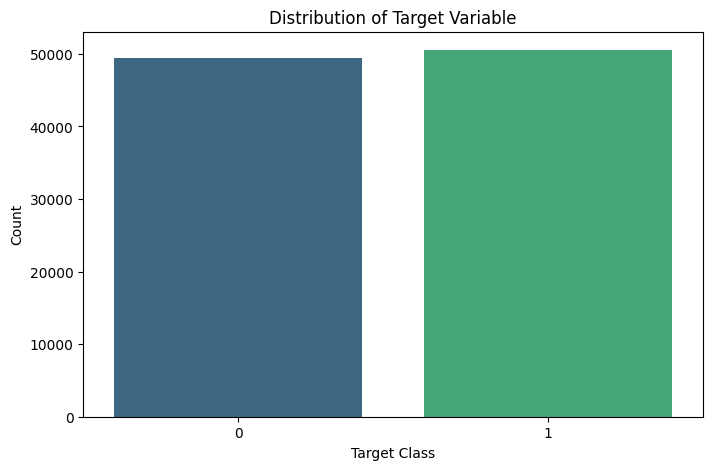

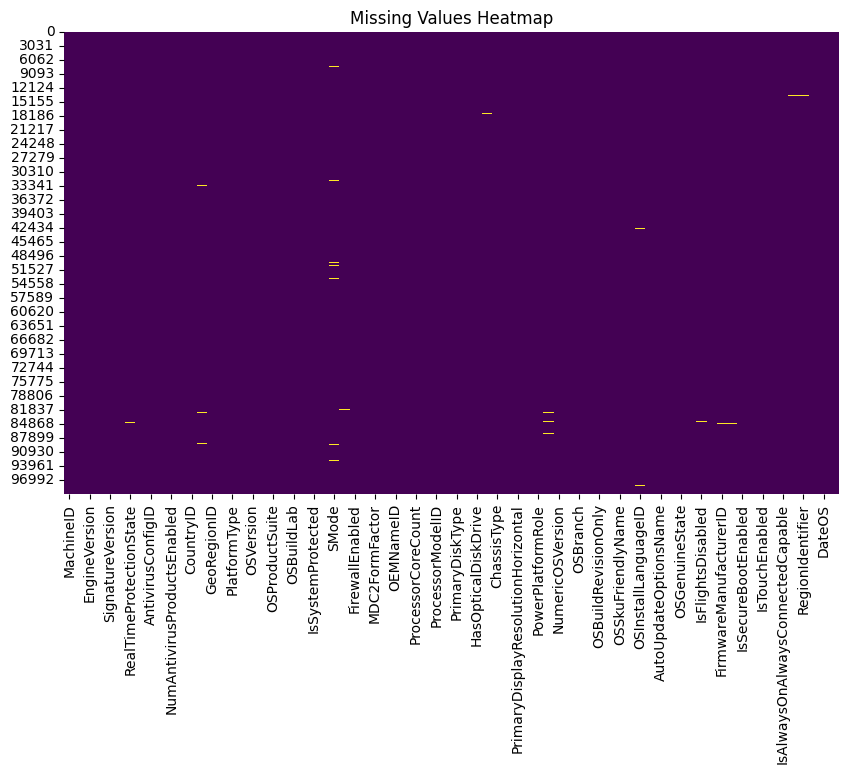

In [2]:
import matplotlib.pyplot as plt  # For visualization
import seaborn as sns  # For better-looking graphs

# Set a simple style
plt.style.use('default')  # Avoids deprecated 'seaborn' style warning

# Convert any infinite values to NaN to avoid plotting errors
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)


#Check dataset information
print("Training Data Information:")
print(train_df.info())  # Shows column data types and missing values

#Check summary statistics
print("\nTraining Data Summary:")
print(train_df.describe())  # Shows statistical insights for numerical features

#Check for missing values
missing_values = train_df.isnull().sum()
print("\nMissing Values in Training Data:")
print(missing_values[missing_values > 0])  # Shows only columns with missing values

# 4. Check class distribution of target variable
plt.figure(figsize=(8, 5))
sns.countplot(x=train_df["target"], palette="viridis")
plt.title("Distribution of Target Variable")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of missing values
plt.figure(figsize=(10,6))
sns.heatmap(train_df.isnull(), cmap='viridis', cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


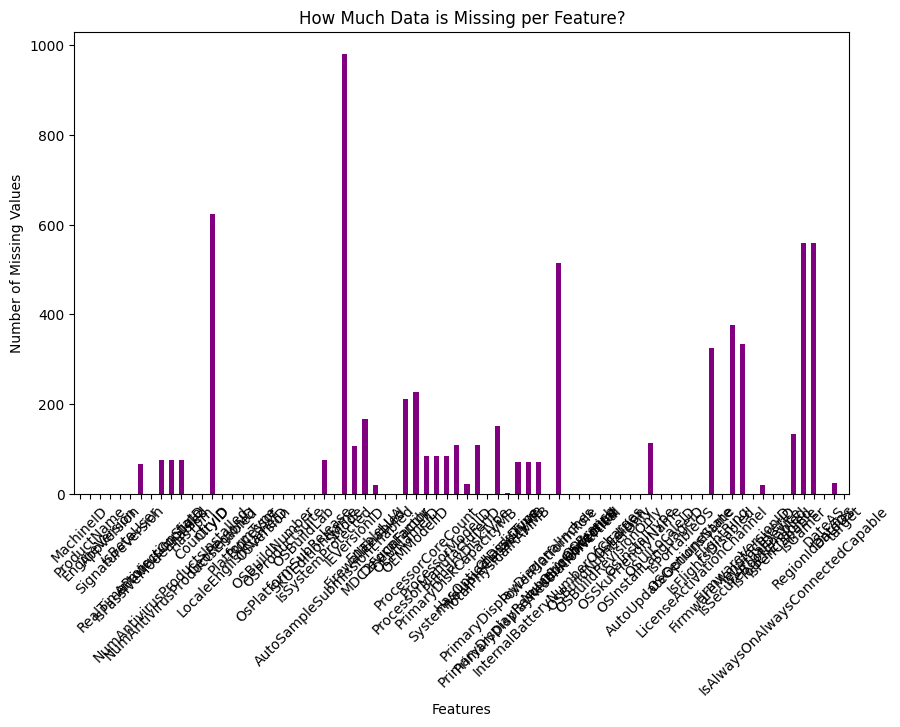

Insight: Features with big bars might affect my threat predictions.


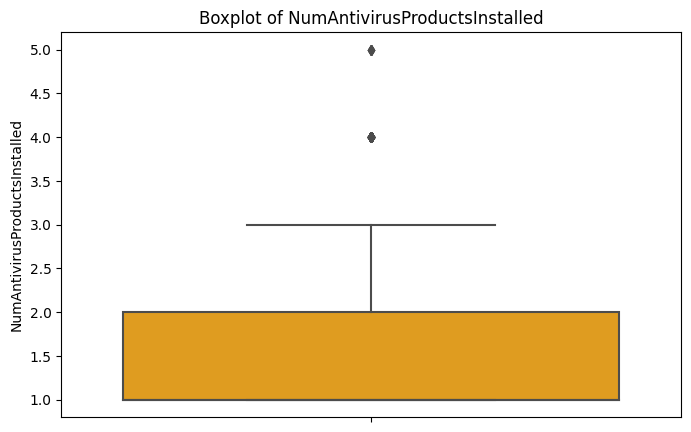

Insight: Dots outside the box are outliers in NumAntivirusProductsInstalled—could they be threats?


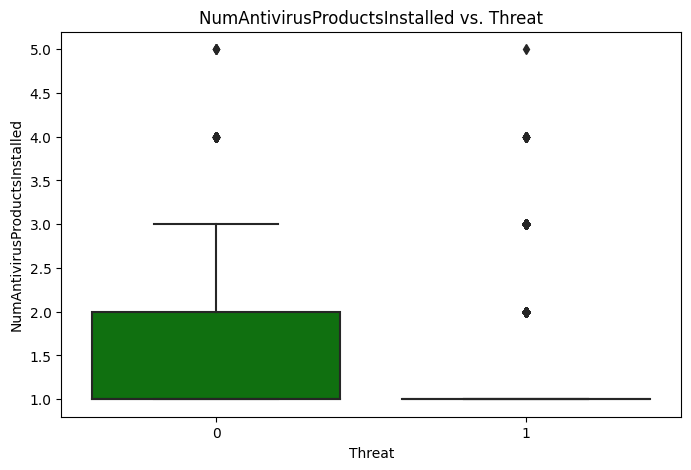

Insight: Does NumAntivirusProductsInstalled look different for threats?


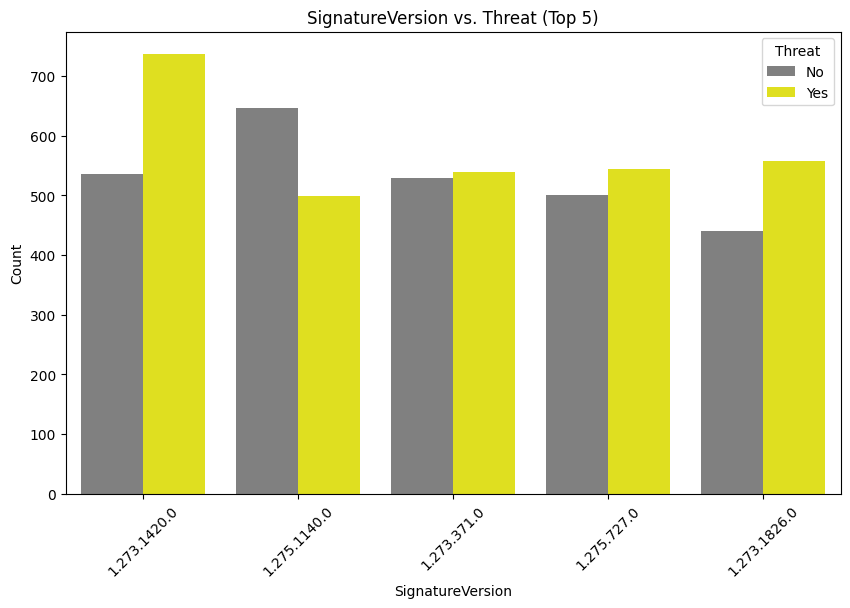

Insight: Are some SignatureVersion values linked to threats?


In [3]:
# Define features
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if "target" in numerical_features:
    numerical_features.remove("target")  # Still remove target from numerical list for graphing


num_feature = numerical_features[4] if len(numerical_features) > 4 else numerical_features[0] if numerical_features else None
cat_feature = categorical_features[4] if categorical_features else None

# Bar Plot of Missing Values per Feature
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='purple')
plt.title("How Much Data is Missing per Feature?")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()
print("Insight: Features with big bars might affect my threat predictions.")

# Boxplot for the 5th Numerical Feature
if num_feature:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=train_df[num_feature], color='orange')
    plt.title(f"Boxplot of {num_feature}")
    plt.ylabel(num_feature)
    plt.show()
    print(f"Insight: Dots outside the box are outliers in {num_feature}—could they be threats?")
else:
    print("No numerical features available for boxplot.")



#  Numerical Feature vs. Target
if num_feature:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='target', y=num_feature, data=train_df, palette=['green', 'pink'])
    plt.title(f"{num_feature} vs. Threat")
    plt.xlabel("Threat")
    plt.ylabel(num_feature)
    plt.show()
    print(f"Insight: Does {num_feature} look different for threats?")
else:
    print("No numerical features for threat comparison.")

# 7.Categorical Feature vs. Target
if cat_feature:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=cat_feature, hue='target', data=train_df, palette=['gray', 'yellow'], order=train_df[cat_feature].value_counts().index[:5])
    plt.title(f"{cat_feature} vs. Threat (Top 5)")
    plt.xlabel(cat_feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend(title="Threat", labels=['No', 'Yes'])
    plt.show()
    print(f"Insight: Are some {cat_feature} values linked to threats?")
else:
    print("No categorical features for threat plot.")


#train_df = train_df.drop(index=12993)

## Handling Missing Data & Identifying Feature Types

In [4]:
# #Identify categorical and numerical columns
# categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
# numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# #Remove the target variable from numerical features
# if "target" in numerical_features:
#     numerical_features.remove("target")

#     train_df = train_df.drop(index=12993)


#Fill missing values in numerical columns with median
for col in numerical_features:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(train_df[col].median())  # Use train median for consistency

#Fill missing values in categorical columns with the most frequent value
for col in categorical_features:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    test_df[col] = test_df[col].fillna(train_df[col].mode()[0])  # Use train mode for consistency



#Check if missing values are handled
print("\nMissing Values After Imputation:", train_df.isnull().sum().sum())  # Should be 0
missing_target_rows = train_df[train_df['target'].isnull()]
print(missing_target_rows)





Missing Values After Imputation: 0
Empty DataFrame
Columns: [MachineID, ProductName, EngineVersion, AppVersion, SignatureVersion, IsBetaUser, RealTimeProtectionState, IsPassiveModeEnabled, AntivirusConfigID, NumAntivirusProductsInstalled, NumAntivirusProductsEnabled, HasTpm, CountryID, CityID, GeoRegionID, LocaleEnglishNameID, PlatformType, Processor, OSVersion, OSBuildNumber, OSProductSuite, OsPlatformSubRelease, OSBuildLab, SKUEditionName, IsSystemProtected, AutoSampleSubmissionEnabled, SMode, IEVersionID, FirewallEnabled, EnableLUA, MDC2FormFactor, DeviceFamily, OEMNameID, OEMModelID, ProcessorCoreCount, ProcessorManufacturerID, ProcessorModelID, PrimaryDiskCapacityMB, PrimaryDiskType, SystemVolumeCapacityMB, HasOpticalDiskDrive, TotalPhysicalRAMMB, ChassisType, PrimaryDisplayDiagonalInches, PrimaryDisplayResolutionHorizontal, PrimaryDisplayResolutionVertical, PowerPlatformRole, InternalBatteryNumberOfCharges, NumericOSVersion, OSArchitecture, OSBranch, OSBuildNumberOnly, OSBuildRe

# Encoding Categorical Features

In [5]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to categorical columns
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()

    # Fit on training data
    train_df[col] = le.fit_transform(train_df[col])

    # Store encoder for future use
    label_encoders[col] = le

    # Transform test data with handling for unseen categories
    test_df[col] = test_df[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)  # Assign -1 to unseen labels

print("\nSample Encoded Data:")
print(train_df[categorical_features].head())  # Display transformed categorical features



Sample Encoded Data:
   MachineID  ProductName  EngineVersion  AppVersion  SignatureVersion  \
0      95607            1             34          31              2218   
1      85800            1             33          31              1906   
2      98689            1             34          31              2331   
3      21877            1             34          17              2253   
4      19567            1             34          22              2265   

   PlatformType  Processor  OSVersion  OsPlatformSubRelease  OSBuildLab  ...  \
0             0          2          0                     1         139  ...   
1             0          1          0                     4         184  ...   
2             0          1          0                     4         184  ...   
3             0          1          0                     2         175  ...   
4             0          2          0                     4         186  ...   

   OSBranch  OSEdition  OSSkuFriendlyName  OSInstall

## Some more plots


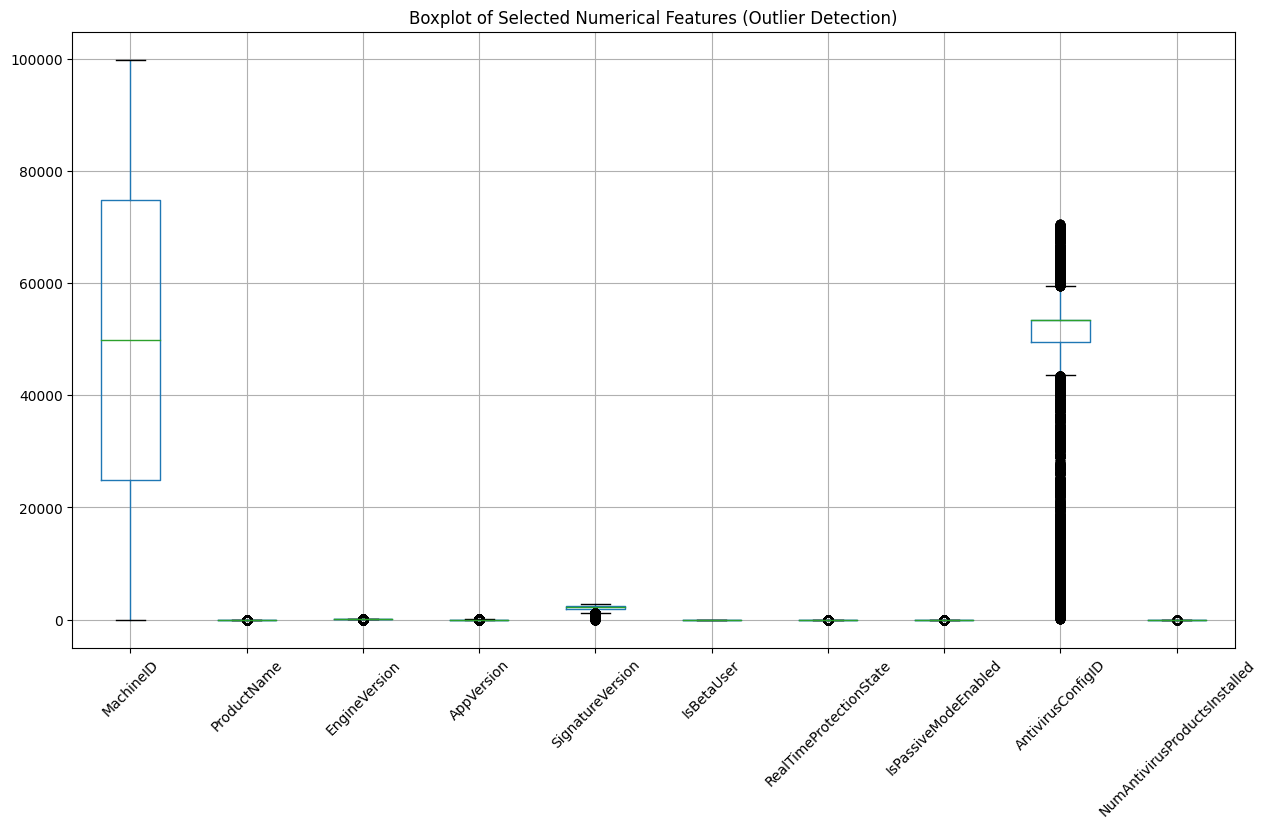

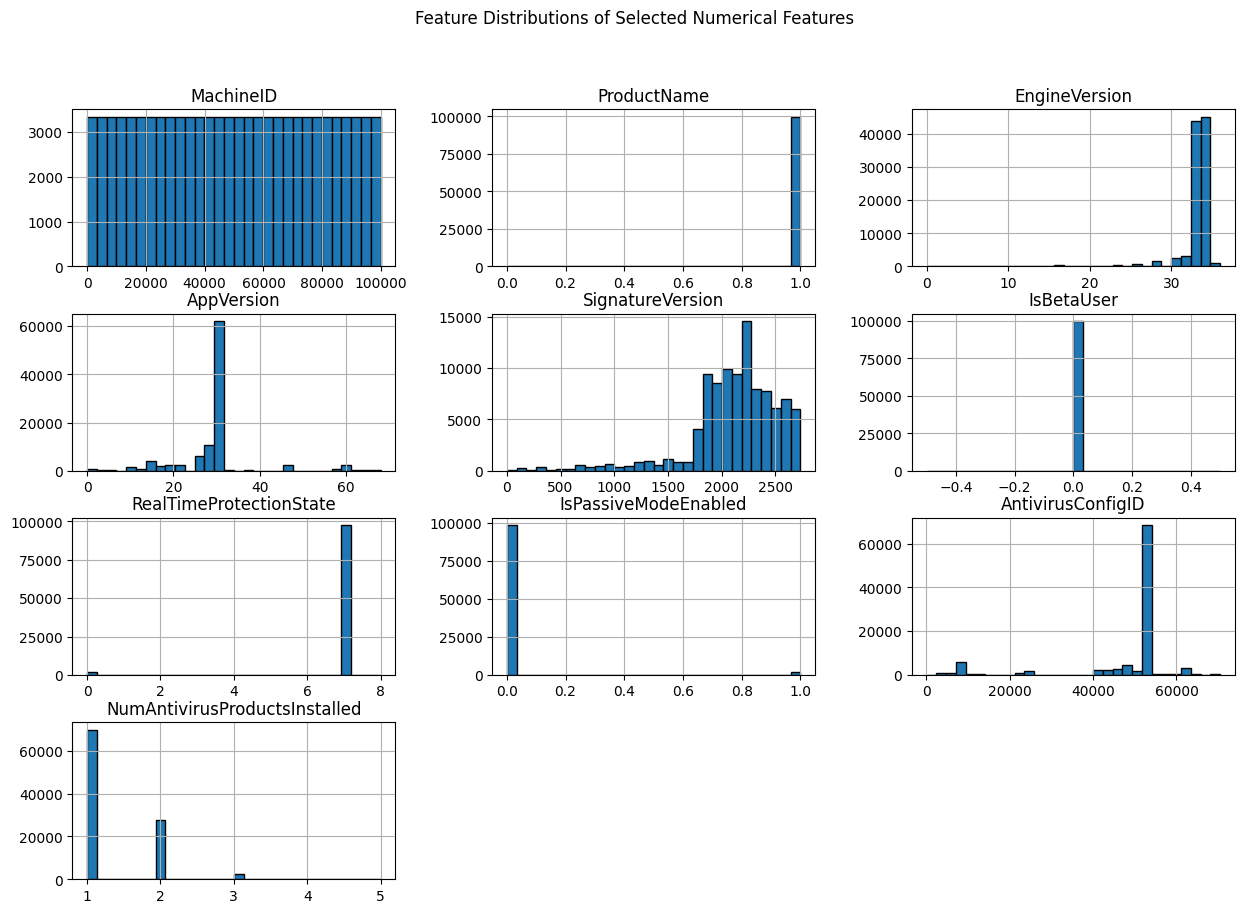

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


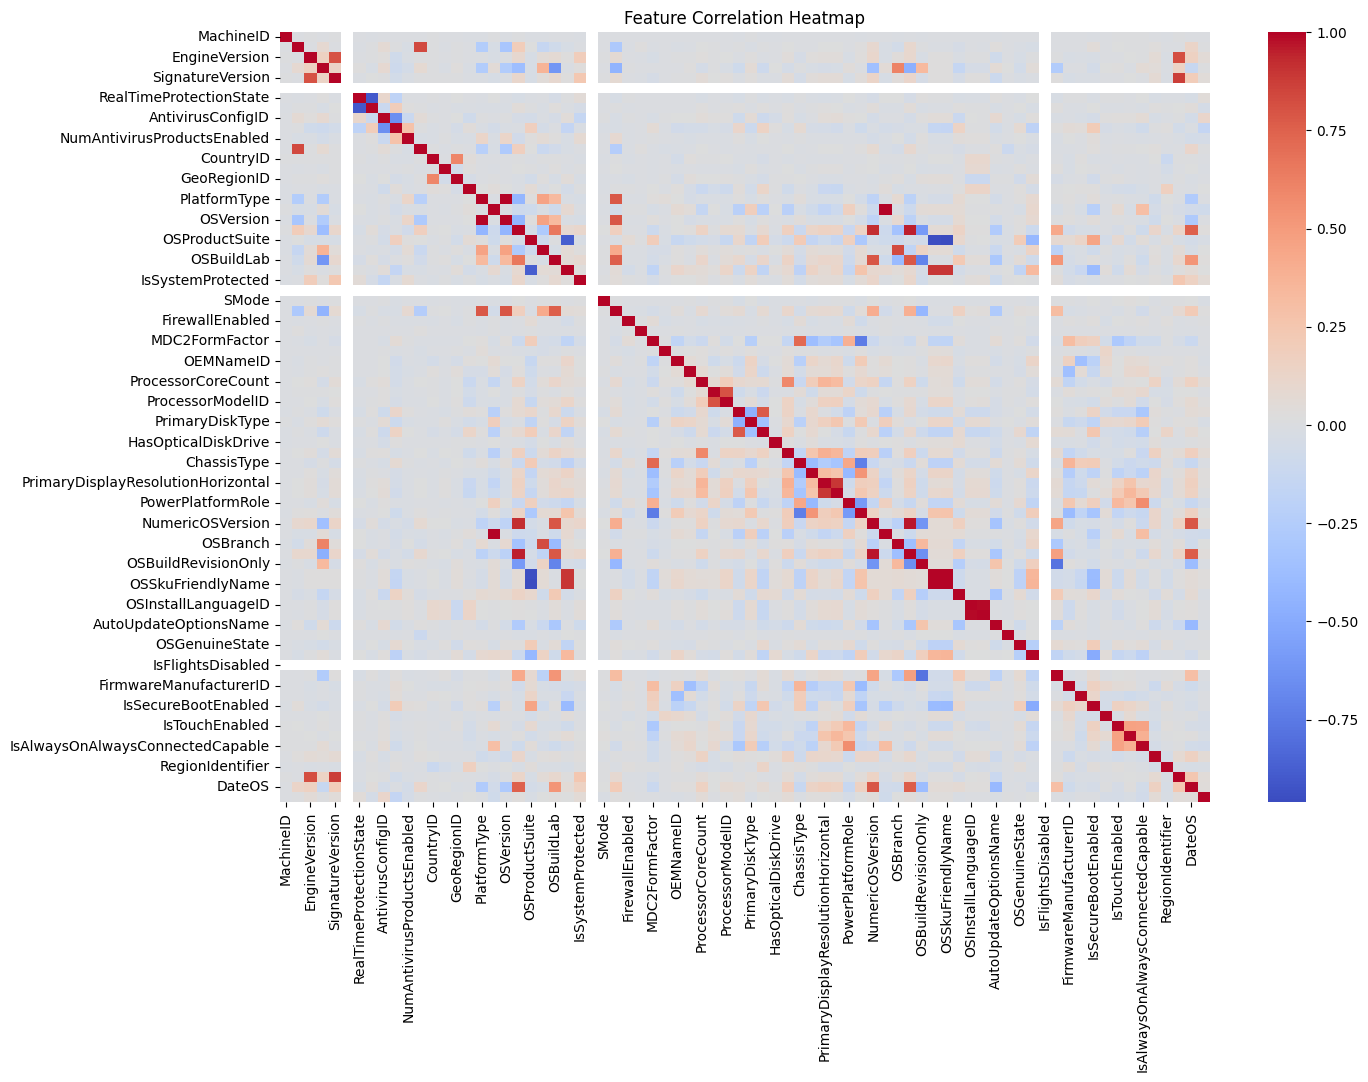

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

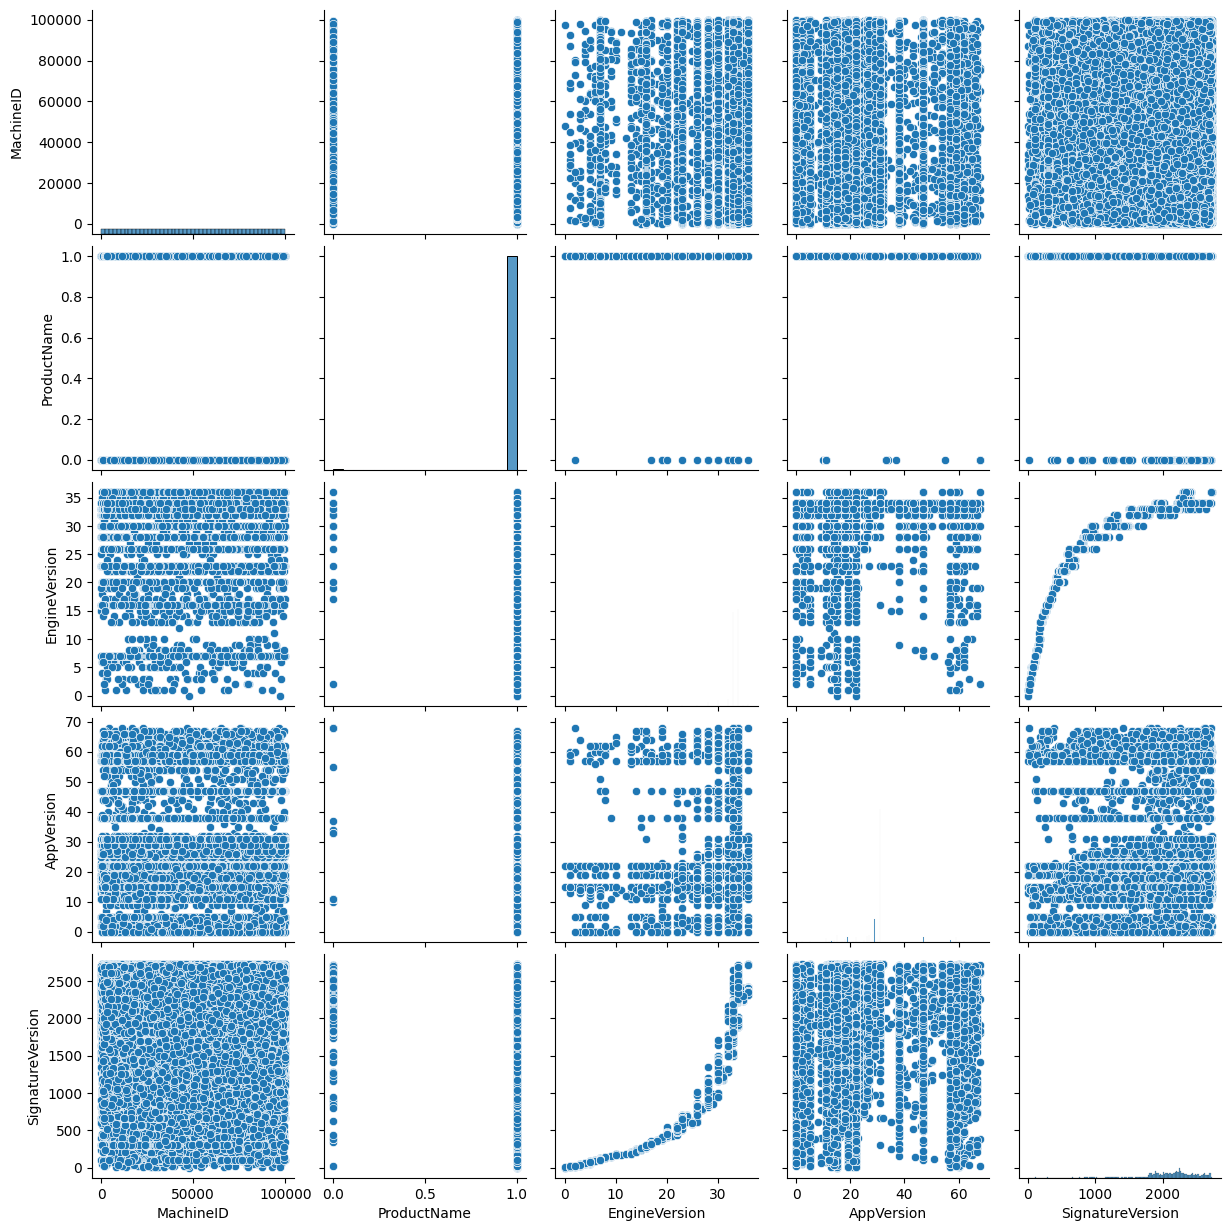

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of selected numerical features
selected_features = train_df.select_dtypes(include=['number']).columns[:10]  # First 10 numerical columns
plt.figure(figsize=(15, 8))
train_df[selected_features].boxplot(rot=45)
plt.title("Boxplot of Selected Numerical Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()

# Histogram of selected numerical features
train_df[selected_features].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle("Feature Distributions of Selected Numerical Features")
plt.show()

# Compute correlation matrix and plot heatmap
plt.figure(figsize=(15, 10))
corr_matrix = train_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm")  # Hide text for better visibility
plt.title("Feature Correlation Heatmap")
plt.show()

# Pairplot for a sample of numerical features
sample_features = train_df.select_dtypes(include=['number']).columns[:5]  # Pick first 5 numerical features
sns.pairplot(train_df[sample_features])
plt.show()


# Scaling Numerical Features

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling to numerical features
train_df[numerical_features] = scaler.fit_transform(train_df[numerical_features])
test_df[numerical_features] = scaler.transform(test_df[numerical_features])  # Use same scaler for test data

print("\nScaled Numerical Features (First 5 Rows):")
print(train_df[numerical_features].head())  # Display scaled values

print("\nScaled Numerical Features (First 5 Rows):")
print(test_df[numerical_features].head())



Scaled Numerical Features (First 5 Rows):
   IsBetaUser  RealTimeProtectionState  IsPassiveModeEnabled  \
0         0.0                    0.875                   0.0   
1         0.0                    0.875                   0.0   
2         0.0                    0.875                   0.0   
3         0.0                    0.875                   0.0   
4         0.0                    0.875                   0.0   

   AntivirusConfigID  NumAntivirusProductsInstalled  \
0           0.758087                           0.00   
1           0.758087                           0.00   
2           0.758087                           0.00   
3           0.658245                           0.25   
4           0.573831                           0.25   

   NumAntivirusProductsEnabled  HasTpm  CountryID    CityID  GeoRegionID  ...  \
0                         0.25     1.0   0.226244  0.715838     0.328814  ...   
1                         0.25     1.0   0.633484  0.671908     0.562712  ...  

# Feature Engineering

In [8]:
# Drop MachineID as it is just an identifier
columns_to_drop = ['MachineID']

# Drop the selected columns
train_df.drop(columns=columns_to_drop, axis=1, inplace=True)
test_df.drop(columns=columns_to_drop, axis=1, inplace=True)

print("Remaining Features After Feature Selection:")
print(train_df.columns)
print(test_df.columns)
print(train_df.head())
print(test_df.head())


Remaining Features After Feature Selection:
Index(['ProductName', 'EngineVersion', 'AppVersion', 'SignatureVersion',
       'IsBetaUser', 'RealTimeProtectionState', 'IsPassiveModeEnabled',
       'AntivirusConfigID', 'NumAntivirusProductsInstalled',
       'NumAntivirusProductsEnabled', 'HasTpm', 'CountryID', 'CityID',
       'GeoRegionID', 'LocaleEnglishNameID', 'PlatformType', 'Processor',
       'OSVersion', 'OSBuildNumber', 'OSProductSuite', 'OsPlatformSubRelease',
       'OSBuildLab', 'SKUEditionName', 'IsSystemProtected',
       'AutoSampleSubmissionEnabled', 'SMode', 'IEVersionID',
       'FirewallEnabled', 'EnableLUA', 'MDC2FormFactor', 'DeviceFamily',
       'OEMNameID', 'OEMModelID', 'ProcessorCoreCount',
       'ProcessorManufacturerID', 'ProcessorModelID', 'PrimaryDiskCapacityMB',
       'PrimaryDiskType', 'SystemVolumeCapacityMB', 'HasOpticalDiskDrive',
       'TotalPhysicalRAMMB', 'ChassisType', 'PrimaryDisplayDiagonalInches',
       'PrimaryDisplayResolutionHorizontal',


# Feature Extraction (Creating New Features)

In [9]:

# Convert DateAS column to datetime
train_df['DateAS'] = pd.to_datetime(train_df['DateAS'])
test_df['DateAS'] = pd.to_datetime(test_df['DateAS'])

# Create new feature: OS Age (days since installation)
train_df['OS_Age'] = (pd.to_datetime('today') - train_df['DateAS']).dt.days
test_df['OS_Age'] = (pd.to_datetime('today') - test_df['DateAS']).dt.days

# Drop DateAS column
train_df.drop(columns=['DateAS'], inplace=True)
test_df.drop(columns=['DateAS'], inplace=True)

print("\nNew Feature 'OS_Age' Created:")
print(train_df[['OS_Age']].head())
print(test_df.head())# Updated to remove 'DateOS'




New Feature 'OS_Age' Created:
   OS_Age
0   20170
1   20170
2   20170
3   20170
4   20170
   ProductName  EngineVersion  AppVersion  SignatureVersion  IsBetaUser  \
0            1             33          31              1856         0.0   
1            1             33          11              2061         0.0   
2            1             34          31              2444         0.0   
3            1             36          31              2731         0.0   
4            1             28          26              1144         0.0   

   RealTimeProtectionState  IsPassiveModeEnabled  AntivirusConfigID  \
0                    0.875                   0.0           0.758087   
1                    0.875                   0.0           0.654994   
2                    0.875                   0.0           0.736895   
3                    0.875                   0.0           0.589516   
4                    0.875                   0.0           0.576372   

   NumAntivirusProductsInstalle

# Splitting the Data

In [10]:
from sklearn.model_selection import train_test_split

# Define target variable and features
X = train_df.drop(columns=['target'])  # Features
y = train_df['target']                 # Target variable

# Split data: 80% Training, 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(X_train.head())
print(X_val.head())
print(y_train.head())
print(y_val.head())


Training set size: (80000, 74)
Validation set size: (20000, 74)
       ProductName  EngineVersion  AppVersion  SignatureVersion  IsBetaUser  \
77741            1             34          11              2671         0.0   
69859            1             36          31              2730         0.0   
98748            1             33          31              2194         0.0   
53359            1             33          31              2021         0.0   
59773            1             34          31              2000         0.0   

       RealTimeProtectionState  IsPassiveModeEnabled  AntivirusConfigID  \
77741                    0.875                   0.0           0.758087   
69859                    0.875                   0.0           0.758087   
98748                    0.875                   0.0           0.758087   
53359                    0.875                   0.0           0.758087   
59773                    0.875                   0.0           0.112220   

       Num

# Model Training

## By Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Logistic Regression Model
log_model = LogisticRegression(max_iter=500, solver="saga", random_state=42)
log_model.fit(X_train, y_train)


# Predictions
y_pred_log = log_model.predict(X_val)

# Evaluate Accuracy
log_acc = accuracy_score(y_val, y_pred_log)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")



Logistic Regression Accuracy: 0.5383


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## after Hypertuning Logistic regression

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define parameter grid
log_params = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs']
}

# Initialize model
log_model = LogisticRegression(max_iter=200, random_state=42)

# Perform Randomized Search
log_search = RandomizedSearchCV(log_model, log_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)

# Fit the model
log_search.fit(X_train, y_train)

# Train best model
best_log_model = log_search.best_estimator_

# Make predictions
y_pred_log = best_log_model.predict(X_val)
log_acc_H = accuracy_score(y_val, y_pred_log)

# Print best accuracy and parameters
print(f"Best Logistic Regression Accuracy: {log_acc_H:.4f}")
print("Best Params for Logistic Regression:", log_search.best_params_)


Best Logistic Regression Accuracy: 0.5968
Best Params for Logistic Regression: {'solver': 'liblinear', 'C': 100}


## By Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_val)

# Evaluate Accuracy
rf_acc = accuracy_score(y_val, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")


Random Forest Accuracy: 0.6149


## After hypertuning Random Forest

In [14]:

# Define parameter grid
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Initialize model
rf_model = RandomForestClassifier(random_state=42)

# Perform Randomized Search
rf_search = RandomizedSearchCV(rf_model, rf_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

# Train best model
best_rf_model = rf_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_val)
rf_acc_H = accuracy_score(y_val, y_pred_rf)

print(f"Best Random Forest Accuracy: {rf_acc:.4f}")
print("Best Params for Random Forest:", rf_search.best_params_)


Best Random Forest Accuracy: 0.6149
Best Params for Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}


## By XGBoost

In [15]:
from xgboost import XGBClassifier

# Train XGBoost Model
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_val)

# Evaluate Accuracy
xgb_acc = accuracy_score(y_val, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")


XGBoost Accuracy: 0.6240


## after hypertuning XGBoost

In [16]:
from xgboost import XGBClassifier

# Define parameter grid
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


# Initialize model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Perform Randomized Search
xgb_search = RandomizedSearchCV(xgb_model, xgb_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

# Train best model
best_xgb_model = xgb_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_val)
xgb_acc_H = accuracy_score(y_val, y_pred_xgb)

print(f"Best XGBoost Accuracy: {xgb_acc:.4f}")
print("Best Params for XGBoost:", xgb_search.best_params_)


Best XGBoost Accuracy: 0.6240
Best Params for XGBoost: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


## By Lightbgm

In [17]:
from lightgbm import LGBMClassifier


# Initialize default LightGBM model
lgbm_model = LGBMClassifier(random_state=42)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred_lgbm = lgbm_model.predict(X_val)

# Calculate accuracy
lgbm_acc = accuracy_score(y_val, y_pred_lgbm)

print(f"LightGBM Accuracy (Before Tuning): {lgbm_acc:.4f}")


[LightGBM] [Info] Number of positive: 40420, number of negative: 39580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4566
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505250 -> initscore=0.021001
[LightGBM] [Info] Start training from score 0.021001
LightGBM Accuracy (Before Tuning): 0.6260


## After Hypertuning lightbgm

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter grid
lgbm_params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth': [3, 5, 7, 10],
    'num_leaves': [20, 31, 40, 50],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize model
lgbm_model_tuned = LGBMClassifier(random_state=42)

# Perform Randomized Search
lgbm_search = RandomizedSearchCV(lgbm_model_tuned, lgbm_params, n_iter=10, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
lgbm_search.fit(X_train, y_train)

# Train best model
best_lgbm_model = lgbm_search.best_estimator_
y_pred_lgbm_tuned = best_lgbm_model.predict(X_val)

# Calculate accuracy
lgbm_acc_H = accuracy_score(y_val, y_pred_lgbm_tuned)

print(f"LightGBM Accuracy (After Tuning): {lgbm_acc_H:.4f}")
print("Best Params for LightGBM:", lgbm_search.best_params_)


[LightGBM] [Info] Number of positive: 40420, number of negative: 39580
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4566
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505250 -> initscore=0.021001
[LightGBM] [Info] Start training from score 0.021001
LightGBM Accuracy (After Tuning): 0.6284
Best Params for LightGBM: {'subsample': 1.0, 'num_leaves': 40, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


# graph showing before and after hypertuning model performence

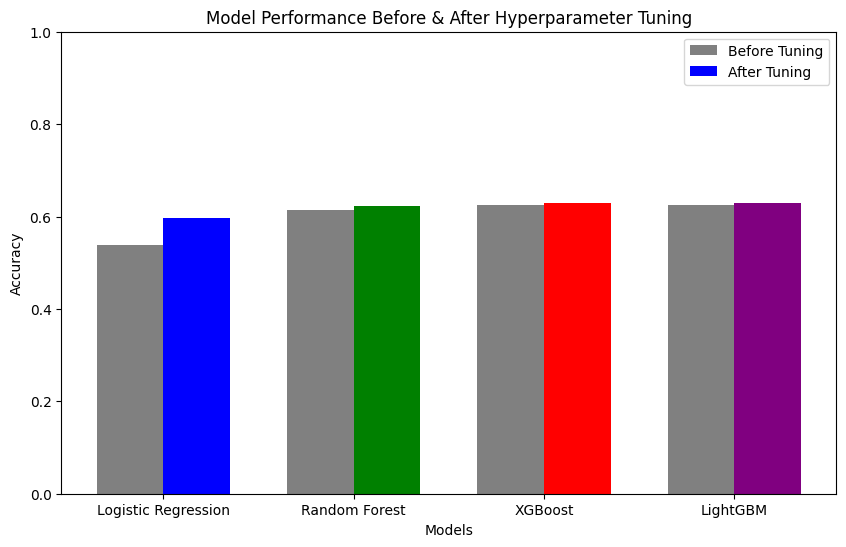

In [19]:


# Model names
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

# Accuracies before and after hyperparameter tuning
accuracies_before = [log_acc, rf_acc, xgb_acc, lgbm_acc]  # Before tuning
accuracies_after = [log_acc_H, rf_acc_H, xgb_acc_H, lgbm_acc_H]  # After tuning

# Bar width
bar_width = 0.35
x = range(len(models))

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(x, accuracies_before, width=bar_width, label='Before Tuning', color='gray')
plt.bar([i + bar_width for i in x], accuracies_after, width=bar_width, label='After Tuning', color=['blue', 'green', 'red', 'purple'])

# Labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Before & After Hyperparameter Tuning')
plt.xticks([i + bar_width / 2 for i in x], models)
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.legend()

# Show plot
plt.show()


# Graph showing top 10 features 

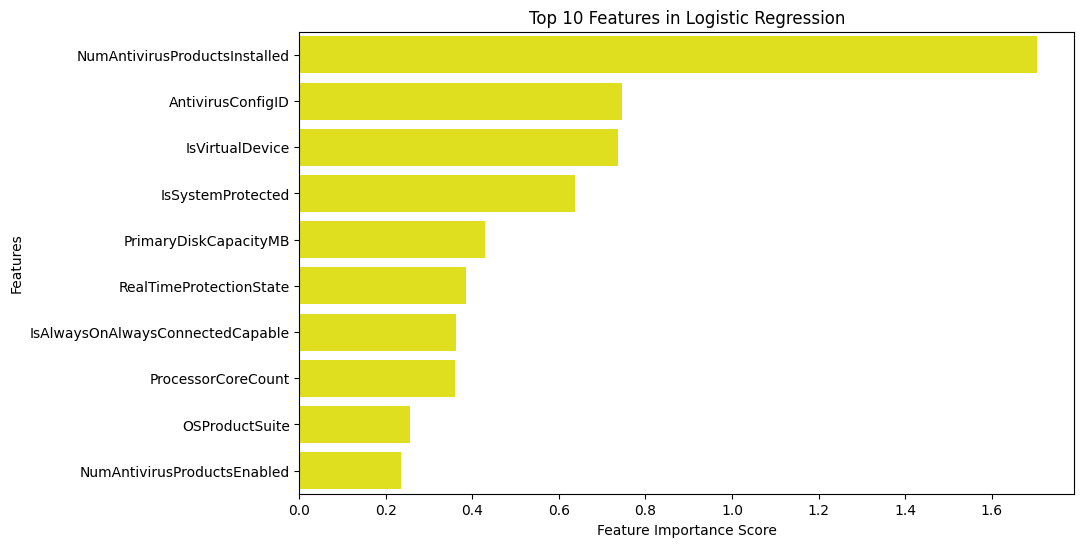

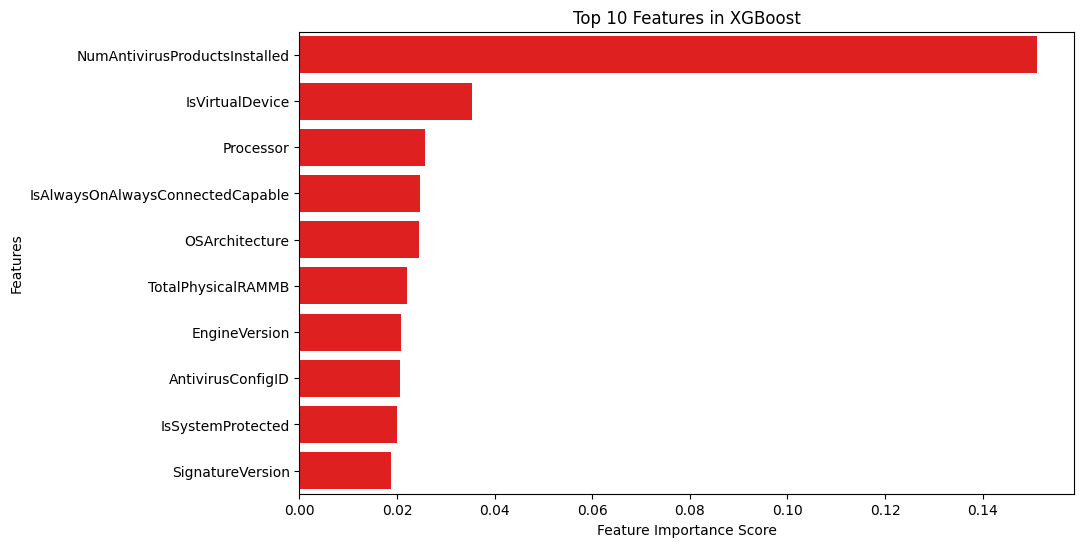

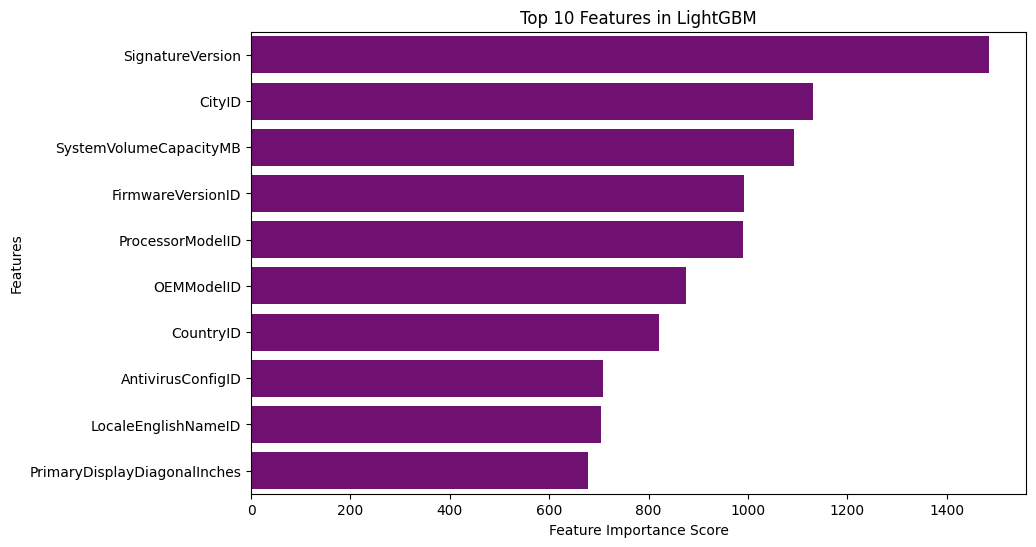

In [20]:
# Function to plot feature importance
def plot_feature_importance(model, X_train, model_name, color):
    if hasattr(model, "feature_importances_"):  # For tree-based models
        importance = model.feature_importances_
    elif hasattr(model, "coef_"):  # For linear models like Logistic Regression
        importance = np.abs(model.coef_[0])  # Take absolute values of coefficients
    else:
        print(f"Feature importance not available for {model_name}")
        return
    
    feature_names = X_train.columns
    sorted_idx = np.argsort(importance)[::-1]
    top_features = min(10, len(feature_names))  # Show up to top 10 features

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importance[sorted_idx][:top_features], 
                y=np.array(feature_names)[sorted_idx][:top_features], 
                color=color)
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title(f"Top {top_features} Features in {model_name}")
    plt.show()

# Feature importance plots
plot_feature_importance(best_log_model, X_train, "Logistic Regression", "yellow")
plot_feature_importance(best_xgb_model, X_train, "XGBoost", "red")
plot_feature_importance(best_lgbm_model, X_train, "LightGBM", "purple")


# submitting the file

In [21]:
# Predict on test_df
y_pred_test = best_lgbm_model.predict(test_df)

# Create a submission datafram
submission = pd.DataFrame({'id': test_df.index, 'target': y_pred_test})

# Save to CSV (without index)
submission.to_csv('submission.csv', index=False)

print("Submission file saved successfully!")
import os
print("Files in current directory:", os.listdir())



Submission file saved successfully!
Files in current directory: ['__notebook__.ipynb', 'submission.csv']
